```python
import numpy as np
import pandas as pd

# 데이터셋 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 기본 데이터셋 정보 확인
train.info()

# 데이터셋의 첫 3개 행 확인
display(train.head(3))
display(test.head(3))
```

```python
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 분포 확인
numerical_features = train.select_dtypes(include=[np.number]).columns.tolist()[:-1]

for feature in numerical_features:
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(train[feature], kde=True)
    plt.title('Distribution of ' + feature)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=train[feature])
    plt.title('Boxplot of ' + feature)
    plt.show()

```

## Exercise_Duration

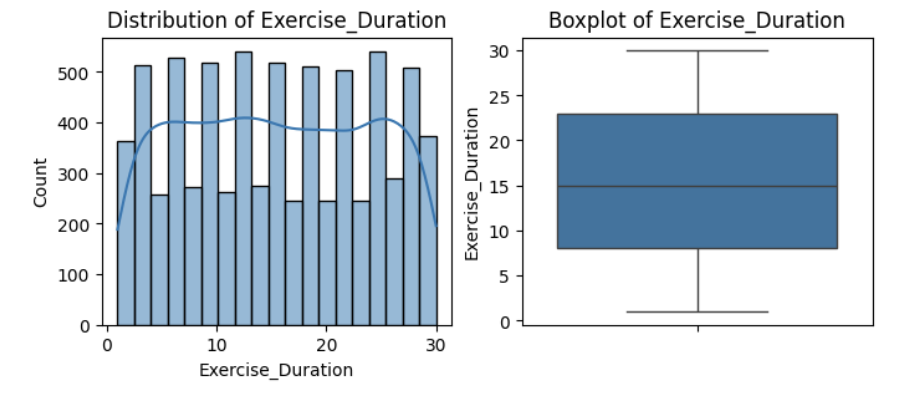

- 분포는 이미 비교적 균일해 보임, 특별한 긴꼬리(skewness)나 이상치(outliers)가 보이지 않음. 표준화를 적용하여 모델에 적용할 수 있지만 필수적으로 요구되지 않음 

## Body_Temperature 히스토 그림

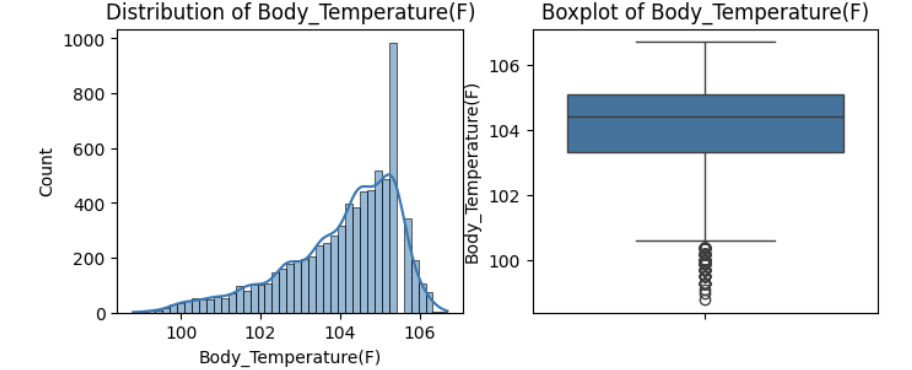

- 체온 데이터가 105F 부근에 집중되어 있음. 주된 분포가 좁은 범위에 집중 
- 급격히 감소하는 긴꼬리가 있음. 데이터 오른쪽에 치우침(skew)가 있음. 데이터의 분포는 정규 분포를 이루지 않으며, 왜도를 줄이기 위해 로그 변환을 고려해야함. 

## Body_Temperature boxplot

- 중앙값이 약 104F 부근에 위치. 
- 상자(1사분위와 3사분위 사이의 범위)는 비교적 좁음, 대부분의 데이터가 비교적 작은 범위내에 있다는 것을 의미 
- 박스아래 수염에서 긴꼬리가 눈에띄며, 이상치가 많다는 것을 나타냄 
- 이러한 이상치들은 모델이 데이터의 중심 경향을 학습하는데 영향을 줄 수 있으므로 주의 깊게 처리해야 할 수 있음. 

## BPM 

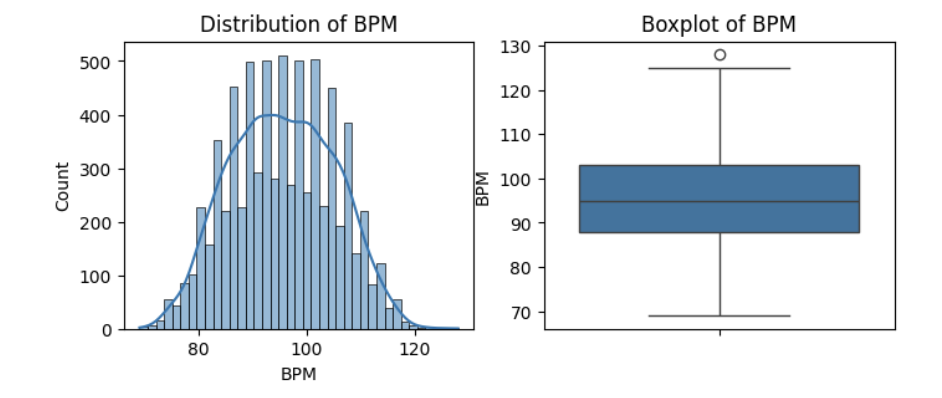

- 정규 분포에 가깝고 이상치가 몇개 보이지만, 로그 변환보다는 표준화 적용이 유리 

## Height

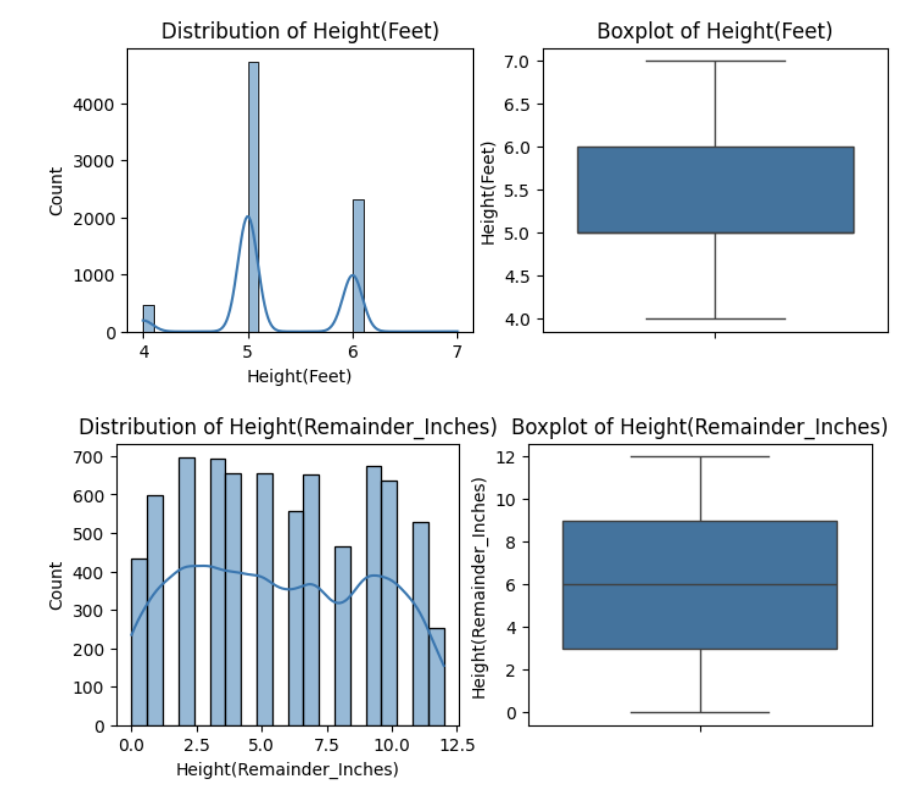

- 이 두변수는 명확하게 이산적인 값을 가지고 있다. 
- Height(Feet)는 명확한 꼬리가 없어 보인다. 
- Height(Remainder_Inches)는 약간의 규칙적인 패턴을 보이는데, 이는 사람들의 키가 주로 특정 값에 집중 되기 때문 일 수 있다. 
- 두변수 모두 로그 변환보다는 표준화를 적용하는것이 유리 

## Weihgt(lb) 히스토 그램 

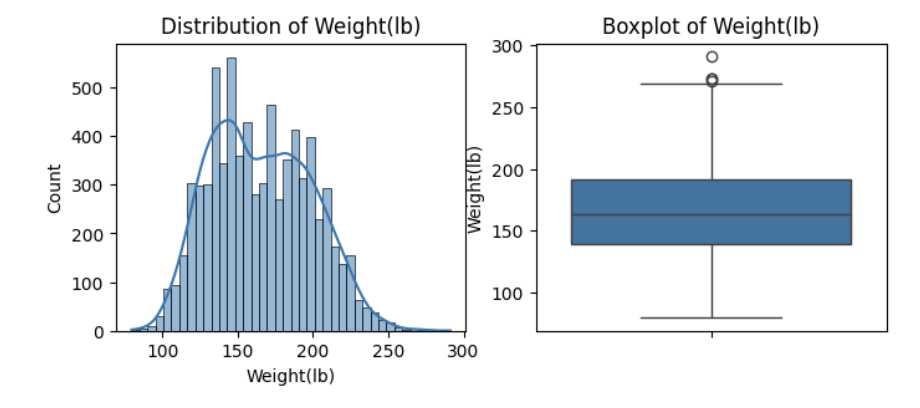

- Weight(lb)데이터의 분포
    - 두개의 주요 봉우리를 가지는 것처럼 보임, 이는 두개의 다른 집단 또는 체중 범위가 데이터 셋에 존재할 수 있음을 시사. 
    - 이경우 단일한 정규 분포보다는 이중 모드 ( bimodal distribution )에 가까움 

## Age

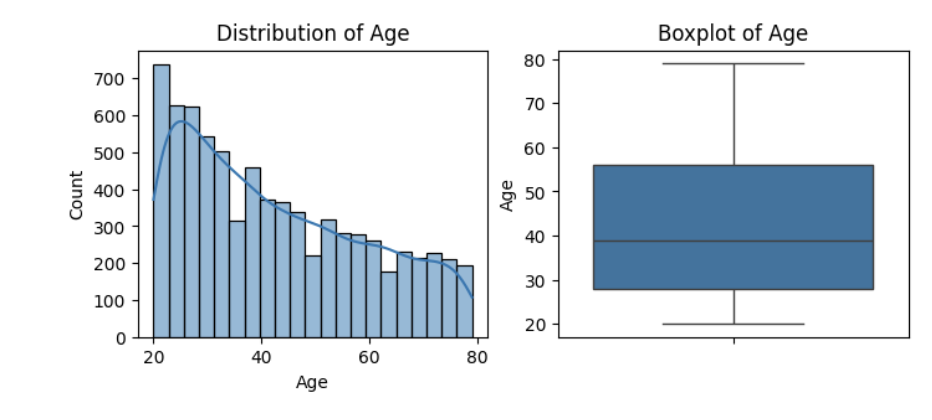

- 나이는 오른쪽으로 긴 꼬리, 대부분의 데이터가 젊은 나이대에 집중 -> 로그 변환을 고려 

### Excercise 

```python
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')

# 타겟 변수와 특성 분리
X = train.drop(['ID', 'Weight_Status', 'Gender', 'Calories_Burned'], axis=1) #범주형 변수들 제거 
y = train['Calories_Burned']

# train_test_split 사용
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state =42)
```

## 피처 표준화 및 로그 스케일

```python
from sklearn.preprocessing import StandardScaler

# 표준화를 적용할 피처들
features_to_scale = ['Exercise_Duration', 'BPM', 'Height(Feet)',
       'Height(Remainder_Inches)', 'Weight(lb)']
# 표준화
scaler = StandardScaler()
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])

# 로그 변환을 적용할 피처
feature_to_log_transform = ['Age', 'Body_Temperature(F)']

# 로그 변환
X_train[feature_to_log_transform] = np.log(X_train[feature_to_log_transform])
X_val[feature_to_log_transform] = np.log(X_val[feature_to_log_transform])
```

## 선형 회귀 모델 구축 및 검증 데이터에 대한 성능 평가 

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 모델 정의
LR_model = LinearRegression()
LR_model.fit(X_train,y_train)
LR_y_pred = LR_model.predict(X_val)

# 성능 평가
LR_rmse = np.sqrt(mean_squared_error(y_val, LR_y_pred)) # RMSE 를 계산, 예측 오차의 제곱에 대한 평균의 제곱근 -> 모델의 예측이 실제 값에서 얼마나 떨어져 있는지?
LR_mae = mean_absolute_error(y_val, LR_y_pred) # 모델의 예측이 실제 값과 평균적으로 얼마나 차이나는지?

print(f'LR_RMSE: {LR_rmse}')
print(f'LR_MAE: {LR_mae}')
```

---

- result 

```
LR_RMSE: 11.146484697011536
LR_MAE: 8.239741059571818
```

## 랜덤 포레스트 회귀 모델 구축 및 성능 평가 

```python
from sklearn.ensemble import RandomForestRegressor

# 모델 정의
RF_model = RandomForestRegressor()
RF_model.fit(X_train, y_train)
RF_y_pred = RF_model.predict(X_val)

# 성능 평가
RF_rmse = np.sqrt(mean_squared_error(y_val, RF_y_pred))
RF_mae = mean_absolute_error(y_val, RF_y_pred)

print(f'RF_RMSE: {RF_rmse}')
print(f'RF_MAE: {RF_mae}')
```

--- 

- result 

```
RF_RMSE: 4.993821629440389
RF_MAE: 3.0026733333333335
```

## 테스트 데이터셋의 전처리 및 랜덤포레스트 모델을 통한 예측 실행 

```python
test = pd.read_csv('test.csv')

X_test = test.drop(['ID','Weight_Status', 'Gender'], axis=1)

# 표준화 적용된 scaler를 사용하여 test 데이터셋의 특정 피처를 변환합니다.
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

# 로그 변환
X_test[feature_to_log_transform] = np.log(X_test[feature_to_log_transform])

# 모델을 사용하여 test 데이터셋에 대한 예측을 수행합니다.
test_predictions = RF_model.predict(X_test)
test_predictions
```

## 제출 

```python
submission = pd.read_csv('sample_submission.csv')
submission['Calories_Burned'] = test_predictions
display(submission.head())

# submission 데이터프레임을 csv 파일로 저장합니다.
submission.to_csv('submission.csv', index=False)
```